# AWP Playground

Configure everything in **Cell 1** below, then **Run All** (Ctrl+Shift+Enter) to execute and see results.

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  AWP PLAYGROUND — EDIT THIS CELL, THEN RUN ALL                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── 1. TASK ─────────────────────────────────────────────────────────────────────
# Describe what you want the agents to do. Be specific.
TASK = (
    "Analyze the sales data: trends per region, revenue vs cost, "
    "create at least 3 visualizations as PNG, and write a summary report as report.md."
)

# ── 2. INPUTS ───────────────────────────────────────────────────────────────────
# Load your data here. Supported types:
#   pd.DataFrame  → CSV in workspace     |  np.ndarray → .npy file
#   str (file)    → copy to workspace     |  dict/list  → JSON (inlined for manager)
#   str (text)    → inline in prompt      |  bytes      → .bin file
#
# NEW: Use Source for remote/offline data (fetched automatically at run time):
#   Source.url()       → HTTP/HTTPS fetch   |  Source.sql()  → SQL query
#   Source.s3()        → S3 object          |  Source.glob() → file pattern match
#   Source.api()       → REST API call      |  Source.base64() → decode base64
#   Source.clipboard() → system clipboard
import pandas as pd, numpy as np
from awp.data import Source

df = pd.DataFrame({
    "date": pd.date_range("2024-01-01", periods=100, freq="D"),
    "revenue": [100 + i * 2.5 + (i % 7) * 10 for i in range(100)],
    "region": ["EU", "US", "APAC", "EU", "US"] * 20,
    "cost": np.random.uniform(50, 200, 100),
})
# df = pd.read_csv("/path/to/your/data.csv")

INPUTS = {
    "sales_data": df,
    # "weights": np.array([0.5, 0.3, 0.2]),
    # "logo": "/path/to/image.png",
    # "config": {"threshold": 0.8, "top_n": 10},
    # "notes": "Focus on EU region",
    #
    # ── Source examples (uncomment to use) ──────────────────────────────────
    # "remote_csv": Source.url("https://example.com/data.csv"),
    # "api_data": Source.api(
    #     "https://api.example.com/v1/metrics",
    #     headers={"Authorization": "Bearer $API_TOKEN"},
    #     jq=".data.items",
    # ),
    # "db_users": Source.sql(
    #     "SELECT * FROM users WHERE active = true",
    #     dsn="$DATABASE_URL",
    # ),
    # "s3_logs": Source.s3("s3://my-bucket/logs/2024-03.parquet"),
    # "local_csvs": Source.glob("/data/reports/*.csv", merge="concat"),
}

# ── 3. MODEL ────────────────────────────────────────────────────────────────────
# OpenRouter format: "openrouter/<provider>/<model>"
MODEL        = "openrouter/openai/gpt-4o-nano"    # Manager model
WORKER_MODEL = None                                # None = same as MODEL

# ── 4. SECRETS ──────────────────────────────────────────────────────────────────
# API keys for tools. Injected transparently — LLMs never see the values.
# Also used by Source resolvers for $SECRET_NAME substitution in headers/DSNs.
import os
SECRETS = {
    # "API_TOKEN": os.getenv("API_TOKEN", ""),
    # "DATABASE_URL": os.getenv("DATABASE_URL", ""),
    # "SERP_API_KEY": os.getenv("SERP_API_KEY", ""),
    # "GITHUB_TOKEN": os.getenv("GITHUB_TOKEN", ""),
}

# ── 5. SKILLS ───────────────────────────────────────────────────────────────────
# Domain knowledge for the manager. Formats: .md file, directory, .zip/.skill
SKILLS = [
    # "path/to/financial_analysis.md",
    # "path/to/data_science_skill/",       # must contain SKILL.md
    # "path/to/domain_knowledge.skill",    # ZIP archive
]

# ── 6. EXTERNAL TOOLS ──────────────────────────────────────────────────────────
# Custom tools available to all agents. Define below or leave empty.
EXTERNAL_TOOLS = [
    # Add your tools here (see examples in Section 6 docs below)
]

# ── 7. BUDGET ───────────────────────────────────────────────────────────────────
# Hard limits the manager cannot override.
MAX_LOOPS      = 100          # Max delegation loop iterations
MAX_TOKENS     = 1_000_000    # Total LLM tokens across all agents
MAX_WALLTIME   = 3000         # Seconds
MAX_TOOL_CALLS = 100          # Tool invocations (code.execute, file.read, ...)
MAX_WORKERS    = 100          # Worker agents
MAX_DEPTH      = 10           # Recursive delegation depth

# ── 8. SANDBOX & PACKAGES ──────────────────────────────────────────────────────
SANDBOX  = "subprocess"       # subprocess | venv | docker | none
PACKAGES = []                 # Pip packages installed before workers run
# PACKAGES += ["seaborn", "scipy", "scikit-learn", "yfinance"]

# ── 9. WORKER CAPABILITIES ─────────────────────────────────────────────────────
CODE_MODE     = True          # Workers can execute Python
TOOL_CREATION = True          # Workers can create tools at runtime (A3)
VERBOSE       = True          # Debug logging

# ── 10. TOOLS ───────────────────────────────────────────────────────────────────
TOOLS = [
    "code.execute", "file.read", "file.write", "file.list", "file.delete",
    "shell.execute", "web.search", "http.request",
    "arithmetic.add", "arithmetic.subtract", "arithmetic.multiply", "arithmetic.divide",
    "memory.read", "memory.write",
]
TOOLS = None
FORBIDDEN_TOOLS = []

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  END OF CONFIGURATION — everything below runs automatically                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

In [2]:
# ── Setup & Execute ─────────────────────────────────────────
import os, time, shutil, subprocess, sys
from pathlib import Path
from dotenv import load_dotenv

# Auto-install awp-agents if not available
try:
    import awp
except ImportError:
    print("Installing awp-agents from PyPI...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "awp-agents[data]", "--quiet"])
    import awp

for env_path in [Path.home() / "projects" / "awp" / ".env", Path(".env")]:
    if env_path.exists():
        load_dotenv(env_path)
        break

if "OPENROUTER_API_KEY" not in os.environ:
    raise RuntimeError("OPENROUTER_API_KEY not found. Create a .env file with it.")
os.environ["LLM_API_KEY"] = os.environ["OPENROUTER_API_KEY"]

from awp.data import AgentWorkflow, ExternalTool, ExternalToolSpec, Source

OUTPUT_DIR = (Path.cwd() / "output").resolve()
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Clean secrets
_secrets = {k: v for k, v in SECRETS.items() if v} or None

# Count Source inputs
source_count = sum(1 for v in INPUTS.values() if isinstance(v, Source))

print(f"Model:      {MODEL}")
print(f"Task:       {TASK[:80]}...")
print(f"Inputs:     {list(INPUTS.keys())} ({source_count} remote Source(s))")
print(f"Secrets:    {list(_secrets.keys()) if _secrets else '(none)'}")
print(f"Skills:     {len(SKILLS)}")
print(f"Ext. tools: {len(EXTERNAL_TOOLS)}")
print(f"Packages:   {PACKAGES}")
print(f"Budget:     loops={MAX_LOOPS}, tokens={MAX_TOKENS:,}, wall={MAX_WALLTIME}s")
print(f"Output:     {OUTPUT_DIR}")
print()

t0 = time.time()

result = AgentWorkflow(
    inputs=INPUTS,
    task=TASK,
    model=MODEL,
    worker_model=WORKER_MODEL,
    max_loops=MAX_LOOPS,
    max_total_tokens=MAX_TOKENS,
    max_wall_time=MAX_WALLTIME,
    max_tool_calls=MAX_TOOL_CALLS,
    max_total_workers=MAX_WORKERS,
    max_depth=MAX_DEPTH,
    sandbox=SANDBOX,
    packages=PACKAGES,
    code_mode=CODE_MODE,
    tool_creation=TOOL_CREATION,
    tools=TOOLS,
    forbidden_tools=FORBIDDEN_TOOLS,
    secrets=_secrets,
    skills=SKILLS or None,
    external_tools=EXTERNAL_TOOLS or None,
    output_dir=str(OUTPUT_DIR),
    verbose=VERBOSE,
).run()

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s — Status: {result['status']}")

INFO:awp.data.workflow:Preparing inputs in workspace: /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output
INFO:awp.data.inputs:Input 'sales_data': DataFrame -> /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output/workspace/inputs/sales_data.csv
INFO:awp.data.workflow:Starting delegation loop: task=Analyze the sales data: trends per region, revenue vs cost, create at least 3 vi
INFO:awp.runtime.delegation_loop_runner:DelegationLoop [2026-03-29_17-30-55_e89d2e2b] depth=0 starting: Analyze the sales data: trends per region, revenue vs cost, create at least 3 vi
INFO:awp.runtime.delegation_loop_runner:=== Iteration 1 ===
DEBUG:awp.runtime.llm:LLM request: model=openai/gpt-4o-nano, messages=2, tools=0
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 400 Bad Request"
DEBUG:awp.runtime.llm:LLM request: model=gpt-5-mini, messages=2, tools=0


Model:      openrouter/openai/gpt-4o-nano
Task:       Analyze the sales data: trends per region, revenue vs cost, create at least 3 vi...
Inputs:     ['sales_data'] (0 remote Source(s))
Secrets:    (none)
Skills:     0
Ext. tools: 0
Packages:   []
Budget:     loops=100, tokens=1,000,000, wall=3000s
Output:     /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output



INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:awp.runtime.delegation_loop_runner:  Spawning worker: regional_sales_analyst
INFO:awp.runtime.delegation_loop_runner:Worker regional_sales_analyst: temperature=0.20 (from default)
DEBUG:awp.runtime.delegation_loop_runner:Worker regional_sales_analyst envelope:
{
  "worker_id": "regional_sales_analyst",
  "instructions": "Read the CSV at inputs/sales_data.csv. Perform the following: 1) Ensure date column is parsed as datetime. 2) Compute and visualize trends per region over time: a) revenue by date per region (line plot, multiple lines) b) cost by date per region (line plot, multiple lines) c) revenue vs cost by region (scatter or bubble with region hue) 3) Create at least 3 visualizations as PNG files and save them to _output_dir with descriptive filenames. Suggested visuals: region_revenue_over_time.png, region_cost_over_time.png, revenue_vs_cost_by_region.png. Optional additional visual


  AWP DELEGATION LOOP DEBUG REPORT
  Model:         openrouter/openai/gpt-4o-nano
  Worker model:  openrouter/openai/gpt-4o-nano
  Budget:        loops=100, workers=100, tokens=1,000,000, wall_time=3000s, depth=10

  ────────────────────────────────────────────────────────
  Iteration 001
  ────────────────────────────────────────────────────────
    ────────────────────────────────────────────────
    MANAGER DECISION
    ────────────────────────────────────────────────
    Decision:    delegate
    Reasoning:
      | The task involves performing data analysis, generating multiple visualizations (PNG) and composing a summary report (report.md). Delegating to a dedicated data-analyst worker with code execution capability ensures proper use of Python (pandas, matplotlib) and output file handling. The worker will read inputs/sales_data.csv, create at least 3 PNG visualizations, and write report.md and visuals to _output_dir.
    Full Manager Decision JSON:
      {
        "decision": "d

## Results

In [3]:
# ── Status overview ─────────────────────────────────────────
meta = result["metadata"]
status = result["status"]
status_icon = "\u2705" if status == "complete" else "\u274c"

print(f"{status_icon} Status:      {status}")
print(f"   Loops:       {meta['loops']}")
print(f"   Wall time:   {meta['wall_time']:.1f}s")
print(f"   Workers:     {meta['workers_spawned']}")
print(f"   Tool calls:  {meta['tool_calls']}")
print(f"   Tokens:      {meta['tokens_used']:,}")
print(f"   Workspace:   {meta['workspace']}")
print(f"   Artifacts:   {len(result['artifacts'])} files")

# Show result summary
r = result["result"]
if isinstance(r, dict):
    print(f"\n   Confidence:  {r.get('confidence', 'N/A')}")
    if "termination_reason" in r:
        print(f"   Terminated:  {r['termination_reason']}")
    if "history_summary" in r:
        hist = r["history_summary"]
        confs = [h["confidence"] for h in hist]
        print(f"   Conf. curve: {' -> '.join(str(c) for c in confs)}")

✅ Status:      complete
   Loops:       2
   Wall time:   146.8s
   Workers:     1
   Tool calls:  2
   Tokens:      0
   Workspace:   /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output
   Artifacts:   5 files

   Confidence:  0.9


## Plots

Found 4 plot(s):



### `output/2026-03-29_17-30-55_e89d2e2b/region_cost_over_time.png` (35 KB)

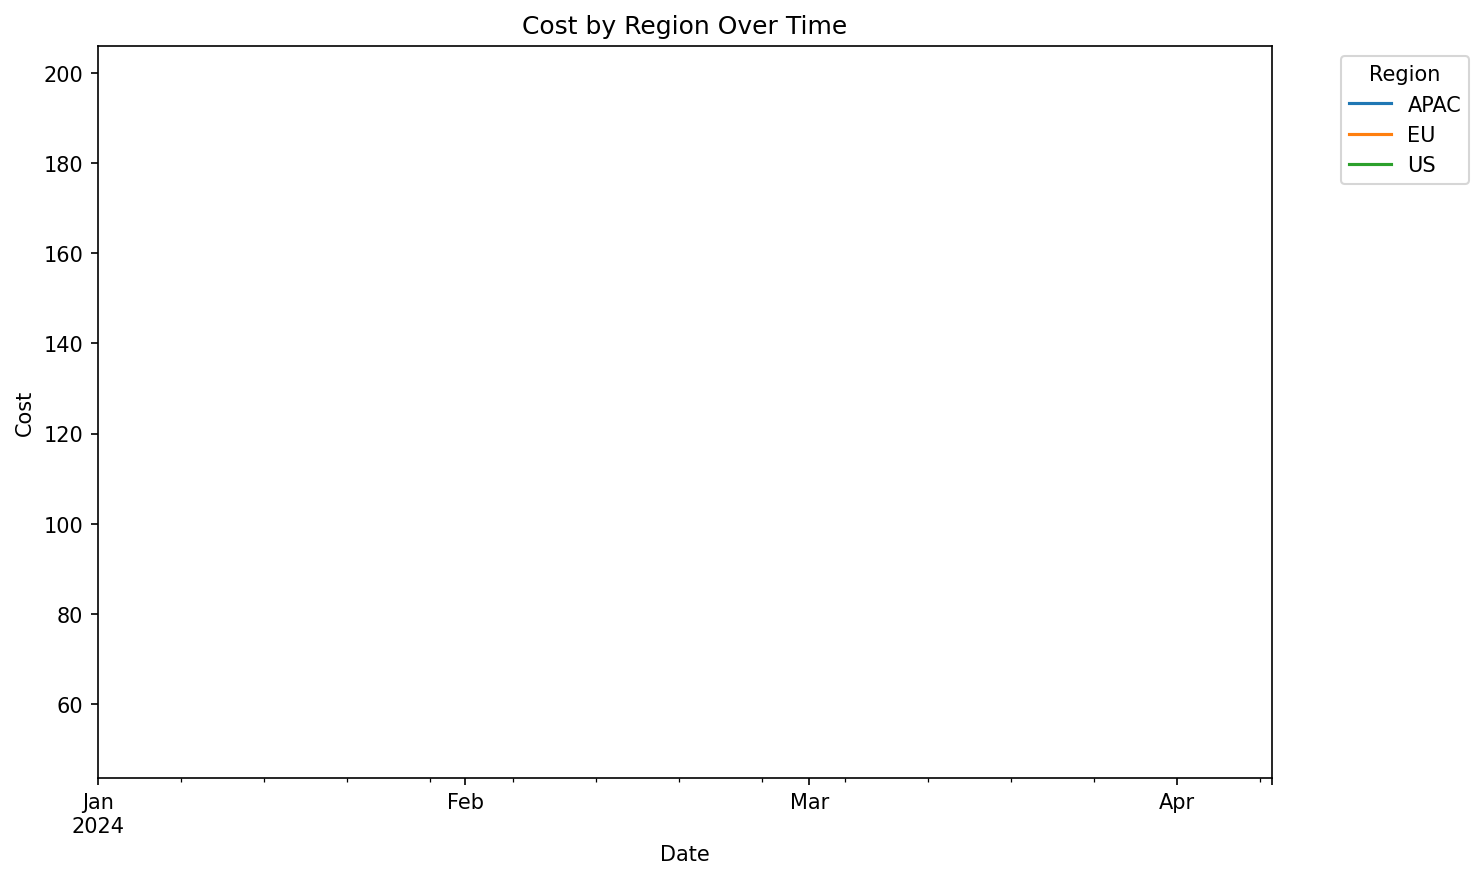

### `output/2026-03-29_17-30-55_e89d2e2b/region_revenue_over_time.png` (36 KB)

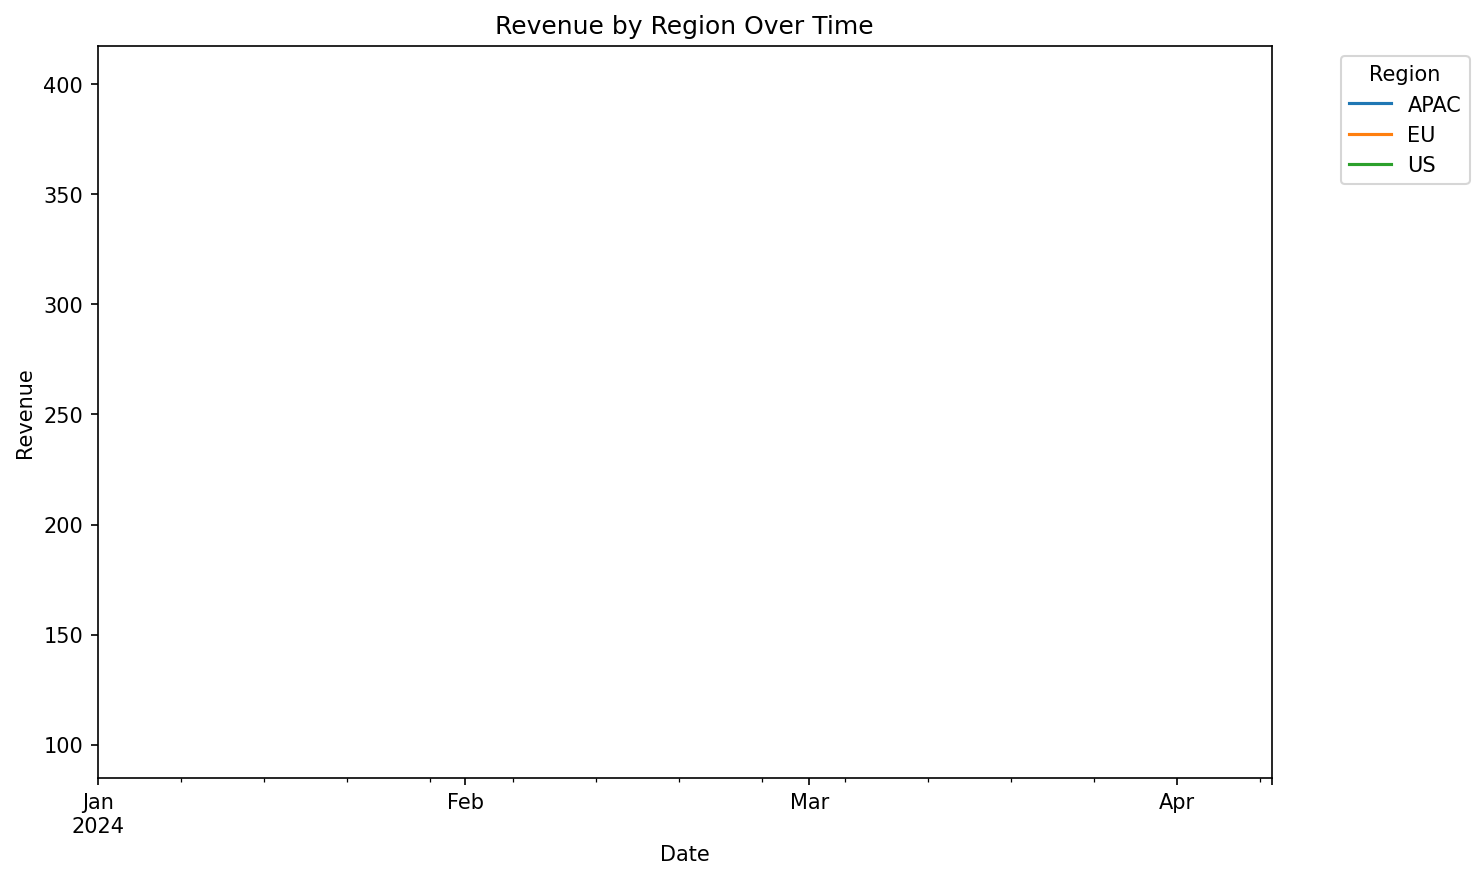

### `output/2026-03-29_17-30-55_e89d2e2b/revenue_vs_cost_by_region.png` (42 KB)

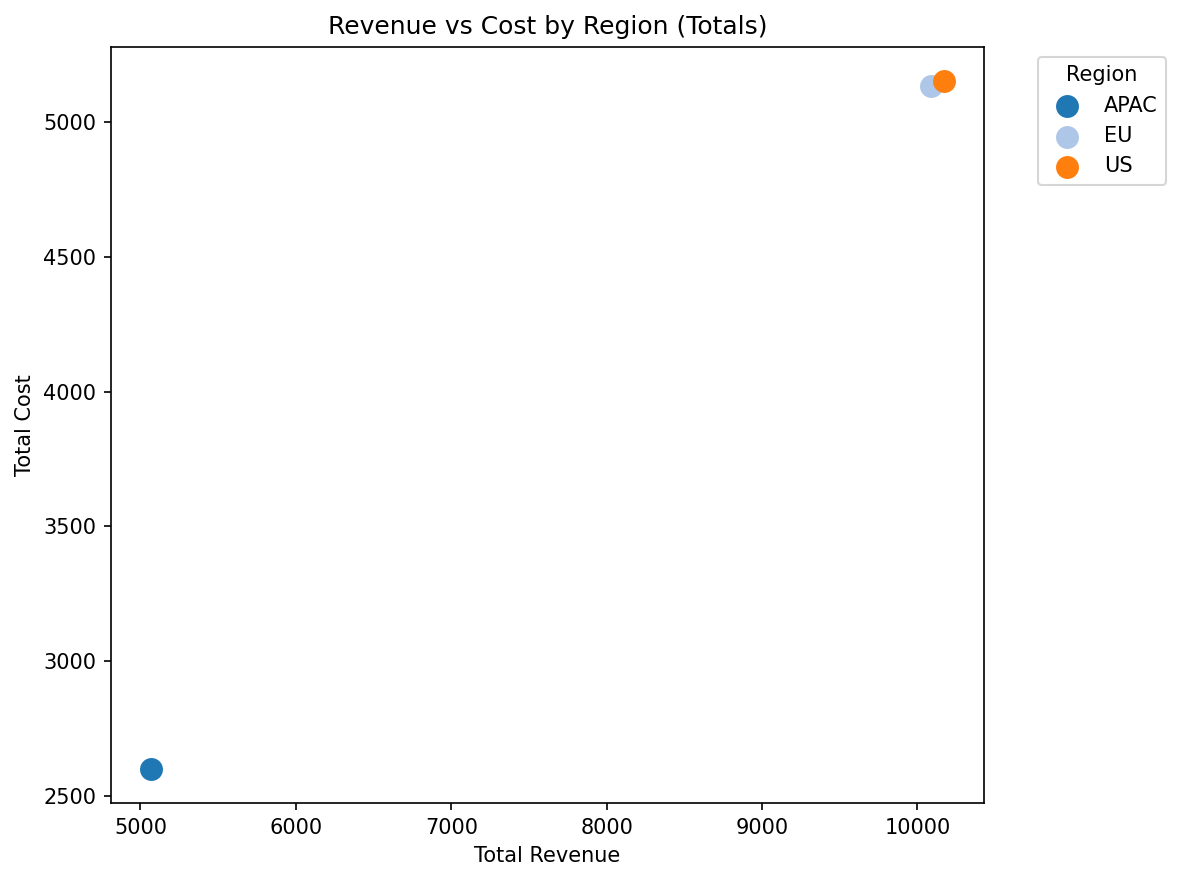

### `output/2026-03-29_17-30-55_e89d2e2b/revenue_vs_cost_over_time_by_region.png` (71 KB)

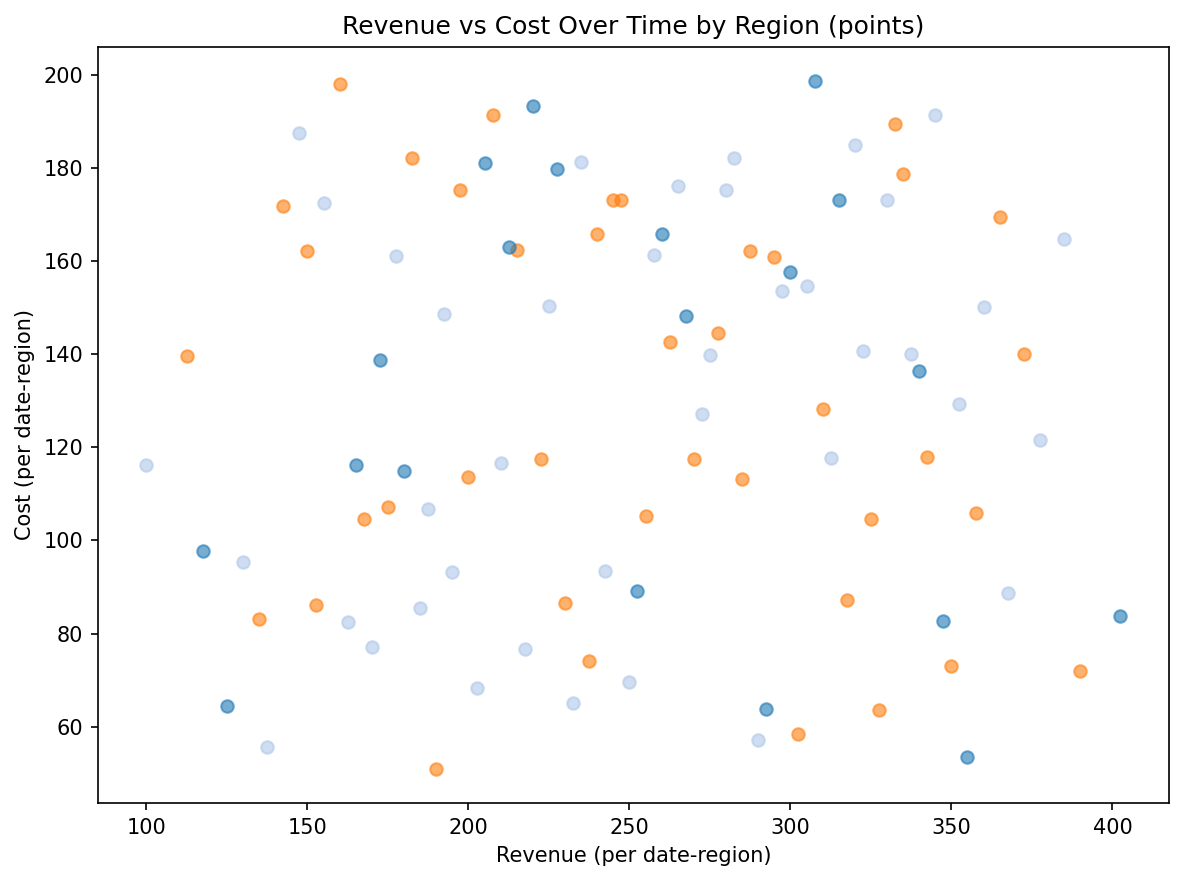

In [4]:
# ── Display all generated PNGs inline ──────────────────────
from IPython.display import display, Image, Markdown
import math

png_files = sorted(
    f for f in OUTPUT_DIR.rglob("*.png")
    if f.stat().st_size > 100  # skip broken placeholders
)

if not png_files:
    print("No PNG files found in output directory.")
else:
    print(f"Found {len(png_files)} plot(s):\n")
    for png in png_files:
        rel = png.relative_to(OUTPUT_DIR)
        size_kb = png.stat().st_size / 1024
        display(Markdown(f"### `{rel}` ({size_kb:.0f} KB)"))
        display(Image(filename=str(png), width=800))
        print()

## Report

In [5]:
# ── Display markdown report if generated ───────────────────
report_dir = OUTPUT_DIR / "output"
md_files = sorted(report_dir.rglob("*.md")) if report_dir.exists() else []

if md_files:
    for md_file in md_files:
        rel = md_file.relative_to(OUTPUT_DIR)
        content = md_file.read_text(encoding="utf-8")
        display(Markdown(f"---\n**File: `{rel}`**\n\n{content}"))
else:
    # Check for .txt reports as fallback
    txt_files = sorted(report_dir.rglob("*.txt")) if report_dir.exists() else []
    if txt_files:
        for txt_file in txt_files:
            rel = txt_file.relative_to(OUTPUT_DIR)
            content = txt_file.read_text(encoding="utf-8")
            print(f"--- {rel} ---")
            print(content)
    else:
        print("No report files found in output directory.")

---
**File: `output/2026-03-29_17-30-55_e89d2e2b/report.md`**

Sales data analysis by region over time.

Date column: date
Region column: region
Revenue column: revenue
Cost column: cost

Key visuals created:
- /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output/output/2026-03-29_17-30-55_e89d2e2b/region_revenue_over_time.png
- /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output/output/2026-03-29_17-30-55_e89d2e2b/region_cost_over_time.png
- /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output/output/2026-03-29_17-30-55_e89d2e2b/revenue_vs_cost_by_region.png
- /home/shumway/projects/agent-workflow-protocol/examples/jupyter/output/output/2026-03-29_17-30-55_e89d2e2b/revenue_vs_cost_over_time_by_region.png

Findings:
- Overall revenue and cost by region are plotted over time to identify trends.
- Revenue vs cost by region shows profitability across regions (where revenue exceeds cost).

Data quality notes:
- No major data quality issues detected.

## Artifacts

In [7]:
# ── List all generated files with sizes ────────────────────
output_path = OUTPUT_DIR / "output"
if output_path.exists():
    total = 0
    files = sorted(output_path.rglob("*"))
    for f in files:
        if f.is_file():
            sz = f.stat().st_size
            total += sz
            rel = str(f.relative_to(OUTPUT_DIR))
            marker = "\u2705" if sz > 100 else "\u274c"
            print(f"  {marker} {rel:<50s} {sz:>8,} bytes")
    print(f"\n  Total: {total:,} bytes in {sum(1 for f in files if f.is_file())} files")
else:
    print("No output directory found.")

  ✅ output/2026-03-29_17-30-55_e89d2e2b/region_cost_over_time.png   36,140 bytes
  ✅ output/2026-03-29_17-30-55_e89d2e2b/region_revenue_over_time.png   37,216 bytes
  ✅ output/2026-03-29_17-30-55_e89d2e2b/report.md           951 bytes
  ✅ output/2026-03-29_17-30-55_e89d2e2b/revenue_vs_cost_by_region.png   43,386 bytes
  ✅ output/2026-03-29_17-30-55_e89d2e2b/revenue_vs_cost_over_time_by_region.png   72,563 bytes

  Total: 190,256 bytes in 5 files
